# Perturbation Prediction with CellDISECT

This tutorial demonstrates how to use CellDISECT for **perturbation prediction** on real single-cell data.  We use the **Norman** combinatorial perturbation dataset from [GEARS](https://doi.org/10.1038/s41586-023-06221-2) and **GenePT** gene embeddings.

CellDISECT treats perturbations as a categorical covariate with **predefined external embeddings** (e.g. GenePT, ESM, scGPT) instead of learned embeddings.  For combinatorial perturbations like `GeneA+GeneB`, the combined embedding is the **sum** of the atomic component embeddings.  This enables:

1. **Seen perturbation prediction** — predicting expression under a perturbation that was part of the training set (single or combinatorial).
2. **Unseen perturbation prediction** — predicting expression under a novel perturbation not seen during training, using its predefined embedding.
3. **Combinatorial perturbation prediction** — predicting expression under simultaneous perturbations (e.g. `GeneA+GeneB`).

We hold out a random set of perturbations for evaluation, train the model on the remaining perturbations, and then evaluate on both **unseen (held-out)** and **seen (training)** perturbations.

## 0. Setup & Data Download

In [1]:
import os
import subprocess
import zipfile

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# Define paths
zip_path = os.path.join(DATA_DIR, "norman.zip")
extract_path = os.path.join(DATA_DIR, "norman")
h5ad_path = os.path.join(extract_path, "perturb_processed.h5ad")

if not os.path.exists(h5ad_path):
    # 1. Download the zip file
    print("Downloading Norman dataset (zip)...")
    subprocess.run(
        ["wget", "-q", "-O", zip_path,
         "https://dataverse.harvard.edu/api/access/datafile/6154020"],
        check=True,
    )
    
    # 2. Extract the zip file
    print(f"Extracting to {extract_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    
    # 3. Clean up the zip file to save space (optional)
    os.remove(zip_path)
    print("Extraction complete. Zip file removed.")
else:
    print(f"Dataset already exists at {h5ad_path}")

# Quick verification
if os.path.exists(h5ad_path):
    print(f"Success! File ready at: {h5ad_path}")

Dataset already exists at data/norman/perturb_processed.h5ad
Success! File ready at: data/norman/perturb_processed.h5ad


In [2]:
genept_zip = os.path.join(DATA_DIR, "GenePT_emebdding_v2.zip")
genept_pickle = os.path.join(DATA_DIR, "GenePT_gene_embedding_ada_text.pickle")

if not os.path.exists(genept_pickle):
    if not os.path.exists(genept_zip):
        print("Downloading GenePT embeddings...")
        subprocess.run(
            ["wget", "-q", "-O", genept_zip,
             "https://zenodo.org/records/10833191/files/GenePT_emebdding_v2.zip?download=1"],
            check=True,
        )
    print("Extracting GenePT embeddings...")
    subprocess.run(
        ["unzip", "-o", "-j", genept_zip,
         "GenePT_gene_embedding_ada_text.pickle", "-d", DATA_DIR],
        check=True,
    )
    print("Done.")
else:
    print(f"GenePT embeddings already exist at {genept_pickle}")

GenePT embeddings already exist at data/GenePT_gene_embedding_ada_text.pickle


In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import pickle
import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import torch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

torch.set_float32_matmul_precision('medium')
scvi.settings.seed = 42

import warnings
warnings.filterwarnings('ignore')

from celldisect import CellDISECT, perturbation_metrics

Global seed set to 0
Global seed set to 42


## 1. Data Preparation

In [4]:
adata = sc.read_h5ad(h5ad_path)
print(f"Loaded: {adata.n_obs} cells x {adata.n_vars} genes")
print(f"Obs columns: {list(adata.obs.columns)}")
adata

Loaded: 91205 cells x 5045 genes
Obs columns: ['condition', 'cell_type', 'dose_val', 'control', 'condition_name']


AnnData object with n_obs × n_vars = 91205 × 5045
    obs: 'condition', 'cell_type', 'dose_val', 'control', 'condition_name'
    var: 'gene_name'
    uns: 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
    layers: 'counts'

### 1.1 Identify perturbation and control columns

The Norman dataset uses `condition` for perturbation labels. Single-gene perturbations are encoded as `ctrl+GENE` or `GENE+ctrl`, and true combinatorial perturbations as `GENEA+GENEB`. The only label without `+` is `ctrl`.

In [5]:
perturbation_key = 'perturbation'
control_label = 'ctrl'

if 'condition' in adata.obs.columns and perturbation_key not in adata.obs.columns:
    adata.obs[perturbation_key] = adata.obs['condition'].copy()

adata.X = adata.layers['counts'].copy()

# Remove empty cells
sc.pp.filter_cells(adata, min_counts=1)

print(f"Perturbation column: '{perturbation_key}'")
print(f"Unique perturbations: {adata.obs[perturbation_key].nunique()}")
print(f"Control cells: {(adata.obs[perturbation_key] == control_label).sum()}")
adata.obs[perturbation_key].value_counts().head(10)

Perturbation column: 'perturbation'
Unique perturbations: 284
Control cells: 7353


perturbation
ctrl             7353
CEBPE+RUNX1T1    1030
KLF1+ctrl         997
TBX3+TBX2         969
SLC4A1+ctrl       853
ETS2+CNN1         785
DUSP9+ETS2        698
UBASH3B+OSR2      677
DUSP9+ctrl        662
ctrl+ETS2         656
Name: count, dtype: int64

### 1.2 Normalize perturbation labels

Single-gene perturbations in the Norman dataset appear as `ctrl+GENE` or `GENE+ctrl`. We strip the `ctrl` component so that single-gene perturbations become just `GENE` and true combinatorial perturbations remain `GENEA+GENEB`. This ensures CellDISECT only looks up real gene embeddings.

In [6]:
DELIMITER = '+'

def normalize_pert_label(label, ctrl='ctrl', delimiter='+'):
    """Strip the ctrl component from perturbation labels.
    
    'ctrl+GENE' / 'GENE+ctrl' -> 'GENE'
    'GENEA+GENEB' -> 'GENEA+GENEB' (unchanged)
    'ctrl' -> 'ctrl' (unchanged)
    """
    if label == ctrl:
        return label
    parts = [p.strip() for p in label.split(delimiter)]
    gene_parts = [p for p in parts if p != ctrl]
    return delimiter.join(gene_parts)

# Show before/after for a few examples
raw_labels = adata.obs[perturbation_key].unique().tolist()
examples = [l for l in raw_labels if l != control_label][:6]
for ex in examples:
    print(f"  '{ex}' -> '{normalize_pert_label(ex)}'")

# Apply normalization
adata.obs[perturbation_key] = adata.obs[perturbation_key].map(
    lambda x: normalize_pert_label(x, ctrl=control_label, delimiter=DELIMITER)
)

print(f"\nAfter normalization:")
print(f"  Unique perturbations: {adata.obs[perturbation_key].nunique()}")
adata.obs[perturbation_key].value_counts().head(10)

  'TSC22D1+ctrl' -> 'TSC22D1'
  'KLF1+MAP2K6' -> 'KLF1+MAP2K6'
  'CEBPE+RUNX1T1' -> 'CEBPE+RUNX1T1'
  'MAML2+ctrl' -> 'MAML2'
  'ctrl+CEBPE' -> 'CEBPE'
  'CBL+PTPN9' -> 'CBL+PTPN9'

After normalization:
  Unique perturbations: 237


perturbation
ctrl             7353
KLF1             1641
BAK1             1171
CEBPE            1039
ETS2             1031
CEBPE+RUNX1T1    1030
UBASH3B           983
TBX3+TBX2         969
OSR2              858
SLC4A1            853
Name: count, dtype: int64

### 1.3 Inspect single vs combinatorial perturbations

In [7]:
all_perts = [p for p in adata.obs[perturbation_key].unique() if p != control_label]
single_perts = [p for p in all_perts if DELIMITER not in p]
combo_perts = [p for p in all_perts if DELIMITER in p]

# Collect all atomic gene names
all_atomic_genes = set()
for p in all_perts:
    all_atomic_genes.update(p.split(DELIMITER))

print(f"Single-gene perturbations: {len(single_perts)}")
print(f"Combinatorial perturbations: {len(combo_perts)}")
print(f"Unique atomic genes across all perturbations: {len(all_atomic_genes)}")
print(f"\nExample singles: {single_perts[:5]}")
print(f"Example combos:  {combo_perts[:5]}")

Single-gene perturbations: 105
Combinatorial perturbations: 131
Unique atomic genes across all perturbations: 105

Example singles: ['TSC22D1', 'MAML2', 'CEBPE', 'DUSP9', 'ELMSAN1']
Example combos:  ['KLF1+MAP2K6', 'CEBPE+RUNX1T1', 'CBL+PTPN9', 'TGFBR2+ETS2', 'SGK1+TBX3']


### 1.4 Load GenePT gene embeddings

In [8]:
with open(genept_pickle, 'rb') as f:
    gene_embeddings_raw = pickle.load(f)

gene_embeddings = {
    k: np.array(v, dtype=np.float32) for k, v in gene_embeddings_raw.items()
}

example_gene = list(gene_embeddings.keys())[0]
print(f"GenePT embeddings: {len(gene_embeddings)} genes")
print(f"Embedding dim: {gene_embeddings[example_gene].shape[0]}")
print(f"Example: '{example_gene}' -> shape {gene_embeddings[example_gene].shape}")

GenePT embeddings: 93800 genes
Embedding dim: 1536
Example: 'A1BG' -> shape (1536,)


### 1.5 Filter to perturbations with available embeddings

For combinatorial perturbations `GeneA+GeneB`, **both** atomic components must have a GenePT embedding. CellDISECT automatically computes the combined embedding by summing.

In [9]:
def has_all_embeddings(pert, emb_dict, delimiter='+'):
    """Check whether all atomic components of a perturbation have embeddings."""
    return all(g in emb_dict for g in pert.split(delimiter) if g != control_label)

perts_with_emb = [p for p in all_perts if has_all_embeddings(p, gene_embeddings, DELIMITER)]
perts_without_emb = [p for p in all_perts if not has_all_embeddings(p, gene_embeddings, DELIMITER)]

print(f"Perturbations with all embeddings: {len(perts_with_emb)}")
print(f"Perturbations missing >=1 embedding (removed): {len(perts_without_emb)}")
if perts_without_emb:
    print(f"  Examples: {perts_without_emb[:5]}")

keep_mask = (
    (adata.obs[perturbation_key] == control_label) |
    (adata.obs[perturbation_key].isin(perts_with_emb))
)
adata = adata[keep_mask].copy()

# Recount
remaining_perts = [p for p in adata.obs[perturbation_key].unique() if p != control_label]
remaining_single = [p for p in remaining_perts if DELIMITER not in p]
remaining_combo = [p for p in remaining_perts if DELIMITER in p]
print(f"\nFiltered: {adata.n_obs} cells")
print(f"  Single-gene perturbations: {len(remaining_single)}")
print(f"  Combinatorial perturbations: {len(remaining_combo)}")
print(f"  Total (+ ctrl): {adata.obs[perturbation_key].nunique()}")

Perturbations with all embeddings: 232
Perturbations missing >=1 embedding (removed): 4
  Examples: ['RHOXF2BB', 'KIAA1804', 'RHOXF2BB+ZBTB25', 'RHOXF2BB+SET']

Filtered: 90231 cells
  Single-gene perturbations: 103
  Combinatorial perturbations: 129
  Total (+ ctrl): 233


### 1.6 Train / test split — hold out random perturbations

We randomly select a set of perturbations as unseen (test). We hold out both single-gene and combinatorial perturbations to evaluate both scenarios.

In [10]:
np.random.seed(42)

N_HOLDOUT_SINGLE = 5
N_HOLDOUT_COMBO = 5

holdout_single = list(np.random.choice(
    remaining_single, size=min(N_HOLDOUT_SINGLE, len(remaining_single)), replace=False
))
holdout_combo = list(np.random.choice(
    remaining_combo, size=min(N_HOLDOUT_COMBO, len(remaining_combo)), replace=False
))
holdout_perts = holdout_single + holdout_combo

train_perts = [p for p in remaining_perts if p not in holdout_perts]
train_single = [p for p in train_perts if DELIMITER not in p]
train_combo = [p for p in train_perts if DELIMITER in p]

print(f"Held-out single-gene perturbations ({len(holdout_single)}): {holdout_single}")
print(f"Held-out combinatorial perturbations ({len(holdout_combo)}): {holdout_combo}")
print(f"\nTraining perturbations: {len(train_perts)} ({len(train_single)} single + {len(train_combo)} combo)")

Held-out single-gene perturbations (5): ['FOXO4', 'FOXL2', 'ARRDC3', 'C19orf26', 'PTPN12']
Held-out combinatorial perturbations (5): ['MAP2K6+IKZF3', 'FEV+ISL2', 'FOXA3+FOXL2', 'LHX1+ELMSAN1', 'FOXA1+FOXL2']

Training perturbations: 222 (98 single + 124 combo)


In [11]:
train_mask = (
    (adata.obs[perturbation_key] == control_label) |
    (adata.obs[perturbation_key].isin(train_perts))
)
adata_train = adata[train_mask].copy()
adata_eval = adata.copy()

print(f"Training data: {adata_train.n_obs} cells, {adata_train.obs[perturbation_key].nunique()} perturbations (incl. ctrl)")
print(f"Evaluation data: {adata_eval.n_obs} cells")

Training data: 86623 cells, 223 perturbations (incl. ctrl)
Evaluation data: 90231 cells


### 1.7 Store embeddings in AnnData

In [12]:
gene_embeddings['ctrl'] = np.zeros_like(gene_embeddings['MAP2K6'])

In [13]:
adata_train.uns['pert_embeddings'] = gene_embeddings
adata_eval.uns['pert_embeddings'] = gene_embeddings

## 2. Model Setup and Training

In [14]:
cats = [perturbation_key]
cell_type_included = True

arch_dict = {'n_layers': 2,
 'n_hidden': 128,
 'n_latent_shared': 32,
 'n_latent_attribute': 32,
 'dropout_rate': 0.1,
 'weighted_classifier': False,
}
train_dict = {
 'max_epochs': 1000,
 'batch_size': 256,
 'recon_weight': 20,
 'cf_weight': 0.8,
 'beta': 0.003,
 'clf_weight': 0.05,
 'adv_clf_weight': 0.014,
 'adv_period': 5,
 'n_cf': 1,
 'early_stopping_patience': 6,
 'early_stopping': True,
 'save_best': True,
 'kappa_optimizer2': False,
 'n_epochs_pretrain_ae': 0,
}

plan_kwargs = {
 'lr': 0.003,
 'weight_decay': 0.00005,
 'ensemble_method_cf': True,
 'lr_patience': 5,
 'lr_factor': 0.5,
 'lr_scheduler_metric': 'loss_validation',
 'n_epochs_kl_warmup': 10,
}

CellDISECT.setup_anndata(
    adata_train,
    layer='counts',
    categorical_covariate_keys=cats,
    continuous_covariate_keys=[],
    perturbation_key=perturbation_key,
    perturbation_embedding_key='pert_embeddings',
    perturbation_combination_delimiter=DELIMITER,
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [15]:
model = CellDISECT(
    adata_train,
    **arch_dict
)
print(model)

CellDISECT Model with the following params: 
n_hidden: 128, n_latent_shared: 32, n_latent_attribute: 32, n_layers: 2, dropout_rate: 0.1, gene_likelihood: zinb, 
latent_distribution: normal
Training status: Not Trained
Model's adata is minified?: False

In [16]:
model.train(**train_dict, plan_kwargs=plan_kwargs, )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-GPU-c92e82f0-acdb-bfba-5c7c-90306242f281/13/0]


Epoch 2/1000:   0%|          | 1/1000 [00:11<3:14:02, 11.65s/it, v_num=1, loss_validation=6.11, x_0_validation=0.279, x_1_validation=0.29, rec_x_cf_validation=0.201, z_1_validation=28.5, ce_validation=5.12, acc_validation=0.087, f1_validation=0.087, adv_ce_validation=4.98, adv_acc_validation=0.0854, adv_f1_validation=0.0854, loss_train=7.74, x_0_train=0.363, x_1_train=0.366, rec_x_cf_train=0.24, z_1_train=21.3, ce_train=5.26, acc_train=0.0682, f1_train=0.0682, adv_ce_train=5.11, adv_acc_train=0.0784, adv_f1_train=0.0784]


Epoch 00001: loss_validation reached. Module best state updated.


Epoch 6/1000:   0%|          | 5/1000 [00:43<2:18:12,  8.33s/it, v_num=1, loss_validation=6.03, x_0_validation=0.278, x_1_validation=0.28, rec_x_cf_validation=0.198, z_1_validation=32.6, ce_validation=5.1, acc_validation=0.0858, f1_validation=0.0858, adv_ce_validation=4.81, adv_acc_validation=0.0941, adv_f1_validation=0.0941, loss_train=6.04, x_0_train=0.278, x_1_train=0.28, rec_x_cf_train=0.198, z_1_train=35.4, ce_train=5.11, acc_train=0.0869, f1_train=0.0869, adv_ce_train=4.84, adv_acc_train=0.0939, adv_f1_train=0.0939]


Epoch 00005: loss_validation reached. Module best state updated.


...

Epoch 558/1000:  56%|█████▌    | 557/1000 [1:24:07<1:08:40,  9.30s/it, v_num=1, loss_validation=4.59, x_0_validation=0.218, x_1_validation=0.223, rec_x_cf_validation=0.187, z_1_validation=7.14, ce_validation=0.225, acc_validation=0.974, f1_validation=0.974, adv_ce_validation=4.6, adv_acc_validation=0.105, adv_f1_validation=0.105, loss_train=4.61, x_0_train=0.219, x_1_train=0.223, rec_x_cf_train=0.187, z_1_train=9, ce_train=0.332, acc_train=0.943, f1_train=0.943, adv_ce_train=4.68, adv_acc_train=0.0998, adv_f1_train=0.0998]  


Epoch 00557: loss_validation reached. Module best state updated.


Epoch 562/1000:  56%|█████▌    | 561/1000 [1:24:44<1:10:38,  9.66s/it, v_num=1, loss_validation=4.61, x_0_validation=0.218, x_1_validation=0.223, rec_x_cf_validation=0.187, z_1_validation=7.93, ce_validation=0.486, acc_validation=0.893, f1_validation=0.893, adv_ce_validation=4.71, adv_acc_validation=0.0989, adv_f1_validation=0.0989, loss_train=4.54, x_0_train=0.219, x_1_train=0.223, rec_x_cf_train=0.187, z_1_train=9.04, ce_train=0.329, acc_train=0.943, f1_train=0.943, adv_ce_train=4.78, adv_acc_train=0.0952, adv_f1_train=0.0952]


Epoch 00561: loss_validation reached. Module best state updated.


Epoch 568/1000:  57%|█████▋    | 568/1000 [1:25:46<1:05:14,  9.06s/it, v_num=1, loss_validation=4.59, x_0_validation=0.218, x_1_validation=0.223, rec_x_cf_validation=0.186, z_1_validation=7.18, ce_validation=0.217, acc_validation=0.977, f1_validation=0.977, adv_ce_validation=4.58, adv_acc_validation=0.107, adv_f1_validation=0.107, loss_train=4.61, x_0_train=0.219, x_1_train=0.223, rec_x_cf_train=0.186, z_1_train=9.03, ce_train=0.318, acc_train=0.945, f1_train=0.945, adv_ce_train=4.63, adv_acc_train=0.104, adv_f1_train=0.104]
Monitored metric loss_validation did not improve in the last 6 records. Best score: 4.587. Signaling Trainer to stop.


In [18]:
model.save(f"norman_celldisect/", overwrite=True)
print("norman_celldisect/")

norman_celldisect/


## 3. Predicting a Single Seen Perturbation

First, let's predict a perturbation that the model has seen during training.

In [19]:
seen_pert = train_single[0]
print(f"Predicting seen single-gene perturbation: '{seen_pert}'")

x_ctrl, x_true, x_pred = model.predict_perturbation(
    adata_eval,
    perturbation=seen_pert,
    source_perturbation=control_label,
    cats=cats,
    perturbation_key=perturbation_key,
    n_samples_from_source=500,
)

print(f"Control shape:   {x_ctrl.shape}")
print(f"True shape:      {x_true.shape}")
print(f"Predicted shape: {x_pred.shape}")

Predicting seen single-gene perturbation: 'TSC22D1'
Control shape:   torch.Size([500, 5045])
True shape:      torch.Size([376, 5045])
Predicted shape: torch.Size([500, 5045])


In [20]:
metrics_seen_single = perturbation_metrics(
    x_pred.numpy(), x_true.numpy(), x_ctrl.numpy(), top_n_de=20
)
print(f"Metrics for seen perturbation '{seen_pert}':")
for k, v in metrics_seen_single.items():
    print(f"  {k}: {v:.4f}")

Metrics for seen perturbation 'TSC22D1':
  pearson_mean: 0.9927
  pearson_delta: 0.0228
  mse: 0.0038
  top20_de_pearson: 0.9298
  top20_de_cosine: 0.3240


## 4. Predicting a Single Unseen Perturbation

Now we predict one of the held-out perturbations that was **not** in the training data. We pass its GenePT embedding via `new_embeddings`.

In [21]:
unseen_pert = holdout_single[0]
print(f"Predicting unseen single-gene perturbation: '{unseen_pert}'")

unseen_embs = {g: gene_embeddings[g] for g in unseen_pert.split(DELIMITER)}

x_ctrl, x_true, x_pred = model.predict_perturbation(
    adata_eval,
    perturbation=unseen_pert,
    source_perturbation=control_label,
    cats=cats,
    perturbation_key=perturbation_key,
    new_embeddings=unseen_embs,
    n_samples_from_source=500,
)

if x_true is not None:
    metrics_unseen_single = perturbation_metrics(
        x_pred.numpy(), x_true.numpy(), x_ctrl.numpy(), top_n_de=20
    )
    print(f"Metrics for unseen perturbation '{unseen_pert}':")
    for k, v in metrics_unseen_single.items():
        print(f"  {k}: {v:.4f}")
else:
    print(f"No ground-truth cells for '{unseen_pert}' in evaluation data.")
    print(f"Predicted shape: {x_pred.shape}")

Predicting unseen single-gene perturbation: 'FOXO4'
Metrics for unseen perturbation 'FOXO4':
  pearson_mean: 0.9841
  pearson_delta: -0.1067
  mse: 0.0100
  top20_de_pearson: 0.9567
  top20_de_cosine: 0.3998


## 5. Predicting an Unseen Combinatorial Perturbation

CellDISECT handles combinatorial perturbations (e.g. `GeneA+GeneB`) by **summing** the atomic component embeddings. Here we predict a held-out combo.

In [22]:
unseen_combo = holdout_combo[0]
print(f"Predicting unseen combinatorial perturbation: '{unseen_combo}'")
print(f"  Components: {unseen_combo.split(DELIMITER)}")

combo_embs = {g: gene_embeddings[g] for g in unseen_combo.split(DELIMITER)}

x_ctrl, x_true, x_pred = model.predict_perturbation(
    adata_eval,
    perturbation=unseen_combo,
    source_perturbation=control_label,
    cats=cats,
    perturbation_key=perturbation_key,
    new_embeddings=combo_embs,
    n_samples_from_source=500,
)

if x_true is not None:
    metrics_unseen_combo = perturbation_metrics(
        x_pred.numpy(), x_true.numpy(), x_ctrl.numpy(), top_n_de=20
    )
    print(f"Metrics for unseen combo '{unseen_combo}':")
    for k, v in metrics_unseen_combo.items():
        print(f"  {k}: {v:.4f}")
else:
    print(f"No ground-truth cells for '{unseen_combo}'.")
    print(f"Predicted shape: {x_pred.shape}")

Predicting unseen combinatorial perturbation: 'MAP2K6+IKZF3'
  Components: ['MAP2K6', 'IKZF3']
Metrics for unseen combo 'MAP2K6+IKZF3':
  pearson_mean: 0.9864
  pearson_delta: 0.6255
  mse: 0.0067
  top20_de_pearson: 0.9028
  top20_de_cosine: 0.9578


## 6. Batch Evaluation with `predict_perturbations`

For systematic evaluation, we use `predict_perturbations` (plural) which processes multiple perturbations efficiently by sharing source cell encoding.

We evaluate:
1. **All held-out (unseen) perturbations** — both single-gene and combinatorial
2. **A random subset of seen perturbations** — to assess reconstruction quality

In [23]:
np.random.seed(42)

N_SEEN_EVAL = min(20, len(train_perts))
seen_eval_perts = list(np.random.choice(train_perts, size=N_SEEN_EVAL, replace=False))

all_eval_perts = holdout_perts + seen_eval_perts

n_eval_single = sum(1 for p in all_eval_perts if DELIMITER not in p)
n_eval_combo = sum(1 for p in all_eval_perts if DELIMITER in p)
print(f"Evaluating {len(holdout_perts)} unseen + {len(seen_eval_perts)} seen = {len(all_eval_perts)} total")
print(f"  ({n_eval_single} single-gene, {n_eval_combo} combinatorial)")

Evaluating 10 unseen + 20 seen = 30 total
  (13 single-gene, 17 combinatorial)


In [24]:
holdout_perts

['FOXO4',
 'FOXL2',
 'ARRDC3',
 'C19orf26',
 'PTPN12',
 'MAP2K6+IKZF3',
 'FEV+ISL2',
 'FOXA3+FOXL2',
 'LHX1+ELMSAN1',
 'FOXA1+FOXL2']

In [25]:
import gc
gc.collect()

14460

In [26]:
# Collect atomic embeddings for all unseen perturbation components
new_embs = {}
for p in holdout_perts:
    for g in p.split(DELIMITER):
        if g not in new_embs:
            new_embs[g] = gene_embeddings[g]

print(f"Providing {len(new_embs)} atomic embeddings for unseen perturbations")

results = model.predict_perturbations(
    adata_eval,
    perturbations=all_eval_perts,
    source_perturbation=control_label,
    cats=cats,
    perturbation_key=perturbation_key,
    new_embeddings=new_embs,
    n_samples_from_source=500,
    batch_size=256,
)

print(f"Predictions returned for {len(results)} perturbations")

Providing 13 atomic embeddings for unseen perturbations
Predictions returned for 30 perturbations


### 6.1 Compute metrics for all evaluated perturbations

In [27]:
records = []

for pert, (x_ctrl_i, x_true_i, x_pred_i) in results.items():
    if x_true_i is None:
        continue
    m = perturbation_metrics(
        x_pred_i.numpy(), x_true_i.numpy(), x_ctrl_i.numpy(), top_n_de=20
    )
    m['perturbation'] = pert
    m['split'] = 'unseen' if pert in holdout_perts else 'seen'
    m['type'] = 'combo' if DELIMITER in pert else 'single'
    records.append(m)

metrics_df = pd.DataFrame(records)
metrics_df = metrics_df.set_index('perturbation')

print(f"Computed metrics for {len(metrics_df)} perturbations")
metrics_df.head(10)

Computed metrics for 30 perturbations


,pearson_mean,pearson_delta,mse,top20_de_pearson,top20_de_cosine,split,type
perturbation,,,,,,,
FOXO4,0.984066,-0.108509,0.009984,0.956673,0.395618,unseen,single
FOXL2,0.988258,-0.029363,0.008701,0.956343,0.260015,unseen,single
ARRDC3,0.991241,-0.181686,0.005321,0.996426,-0.137059,unseen,single
C19orf26,0.992569,0.168080,0.003984,0.972179,0.712447,unseen,single
PTPN12,0.991953,0.432851,0.004374,0.984046,0.895203,unseen,single
MAP2K6+IKZF3,0.986456,0.627291,0.006720,0.903662,0.957571,unseen,combo
FEV+ISL2,0.978671,0.266620,0.016061,0.905176,0.822309,unseen,combo
FOXA3+FOXL2,0.973870,0.179636,0.019634,0.978840,0.831653,unseen,combo
LHX1+ELMSAN1,0.984850,-0.008092,0.008423,0.716356,0.480285,unseen,combo


In [28]:
print("=" * 60)
print("AGGREGATE METRICS")
print("=" * 60)

numeric_cols = [c for c in metrics_df.columns if c not in ('split', 'type')]

for split in ['seen', 'unseen']:
    sub = metrics_df[metrics_df['split'] == split][numeric_cols]
    if len(sub) == 0:
        continue
    print(f"\n--- {split.upper()} perturbations (n={len(sub)}) ---")
    print(sub.describe().loc[['mean', 'std', 'min', 'max']].round(4).to_string())

print("\n" + "=" * 60)
print("BREAKDOWN BY TYPE")
print("=" * 60)

for (split, ptype), sub in metrics_df.groupby(['split', 'type']):
    sub_num = sub[numeric_cols]
    print(f"\n--- {split.upper()} / {ptype.upper()} (n={len(sub_num)}) ---")
    print(sub_num.mean().round(4).to_string())

AGGREGATE METRICS

--- SEEN perturbations (n=20) ---
      pearson_mean  pearson_delta     mse  top20_de_pearson  top20_de_cosine
mean        0.9869         0.3944  0.0083            0.9436           0.7186
std         0.0070         0.2689  0.0056            0.0629           0.4167
min         0.9649        -0.2056  0.0023            0.7382          -0.6895
max         0.9946         0.7890  0.0248            0.9968           0.9941

--- UNSEEN perturbations (n=10) ---
      pearson_mean  pearson_delta     mse  top20_de_pearson  top20_de_cosine
mean        0.9856         0.1521  0.0096            0.9362           0.6096
std         0.0059         0.2488  0.0052            0.0839           0.3531
min         0.9739        -0.1817  0.0040            0.7164          -0.1371
max         0.9926         0.6273  0.0196            0.9964           0.9576

BREAKDOWN BY TYPE

--- SEEN / COMBO (n=12) ---
pearson_mean        0.9839
pearson_delta       0.4859
mse                 0.0107
top20_de_pe

## 7. Visualization

In [29]:
def plot_prediction_scatter(x_pred, x_true, x_ctrl, title='', top_n_de=20):
    """Scatter plot of predicted vs true mean expression."""
    pred_mean = x_pred.numpy().mean(0) if hasattr(x_pred, 'numpy') else np.asarray(x_pred).mean(0)
    true_mean = x_true.numpy().mean(0) if hasattr(x_true, 'numpy') else np.asarray(x_true).mean(0)
    ctrl_mean = x_ctrl.numpy().mean(0) if hasattr(x_ctrl, 'numpy') else np.asarray(x_ctrl).mean(0)

    delta_true = true_mean - ctrl_mean
    de_idx = np.argsort(-np.abs(delta_true))[:top_n_de]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    r_all, _ = pearsonr(pred_mean, true_mean)
    axes[0].scatter(true_mean, pred_mean, s=1, alpha=0.3)
    axes[0].set_xlabel('True mean expression')
    axes[0].set_ylabel('Predicted mean expression')
    axes[0].set_title(f'{title} — All genes (r={r_all:.3f})')
    lims = [min(axes[0].get_xlim()[0], axes[0].get_ylim()[0]),
            max(axes[0].get_xlim()[1], axes[0].get_ylim()[1])]
    axes[0].plot(lims, lims, 'r--', alpha=0.5)

    r_de, _ = pearsonr(pred_mean[de_idx], true_mean[de_idx])
    axes[1].scatter(true_mean[de_idx], pred_mean[de_idx], s=20, alpha=0.7, c='coral')
    axes[1].set_xlabel('True mean expression')
    axes[1].set_ylabel('Predicted mean expression')
    axes[1].set_title(f'{title} — Top {top_n_de} DE genes (r={r_de:.3f})')
    lims = [min(axes[1].get_xlim()[0], axes[1].get_ylim()[0]),
            max(axes[1].get_xlim()[1], axes[1].get_ylim()[1])]
    axes[1].plot(lims, lims, 'r--', alpha=0.5)

    plt.tight_layout()
    plt.show()

### 7.1 Scatter plots for example perturbations

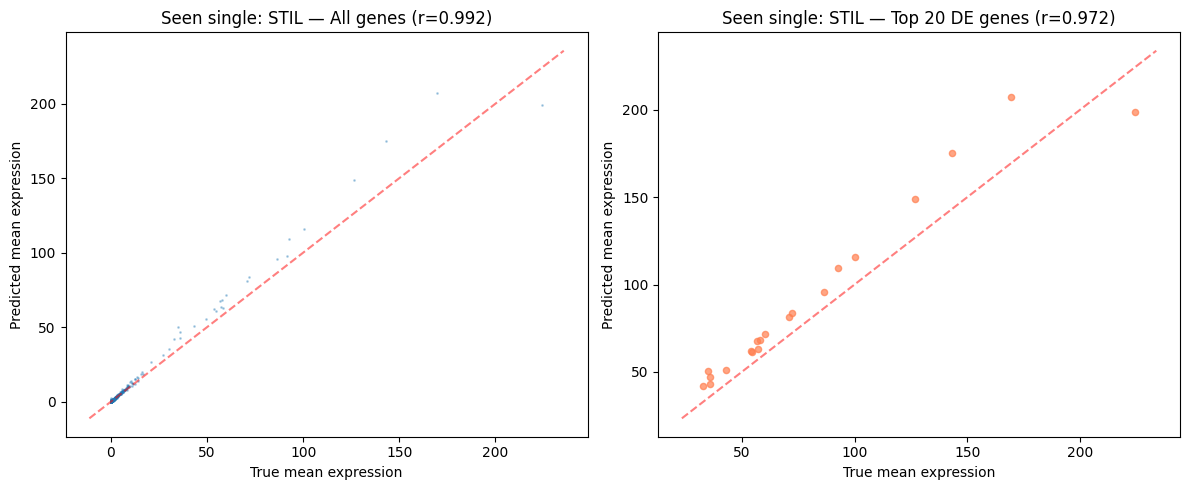

In [30]:
# Seen single-gene perturbation
seen_singles_eval = [p for p in seen_eval_perts if DELIMITER not in p]
if seen_singles_eval:
    pert = seen_singles_eval[0]
    x_c, x_t, x_p = results[pert]
    if x_t is not None:
        plot_prediction_scatter(x_p, x_t, x_c, title=f'Seen single: {pert}')

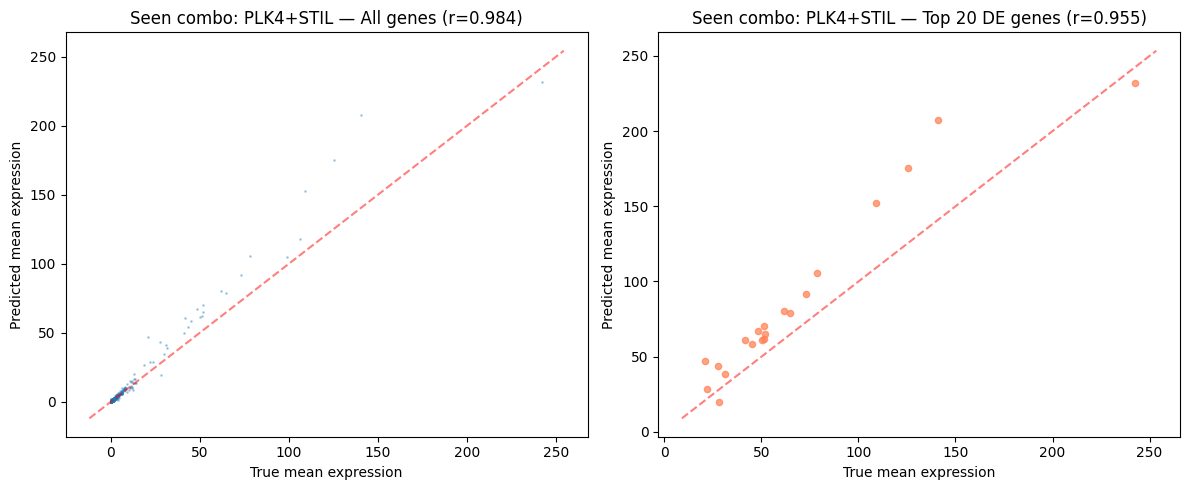

In [31]:
# Seen combinatorial perturbation
seen_combos_eval = [p for p in seen_eval_perts if DELIMITER in p]
if seen_combos_eval:
    pert = seen_combos_eval[0]
    x_c, x_t, x_p = results[pert]
    if x_t is not None:
        plot_prediction_scatter(x_p, x_t, x_c, title=f'Seen combo: {pert}')

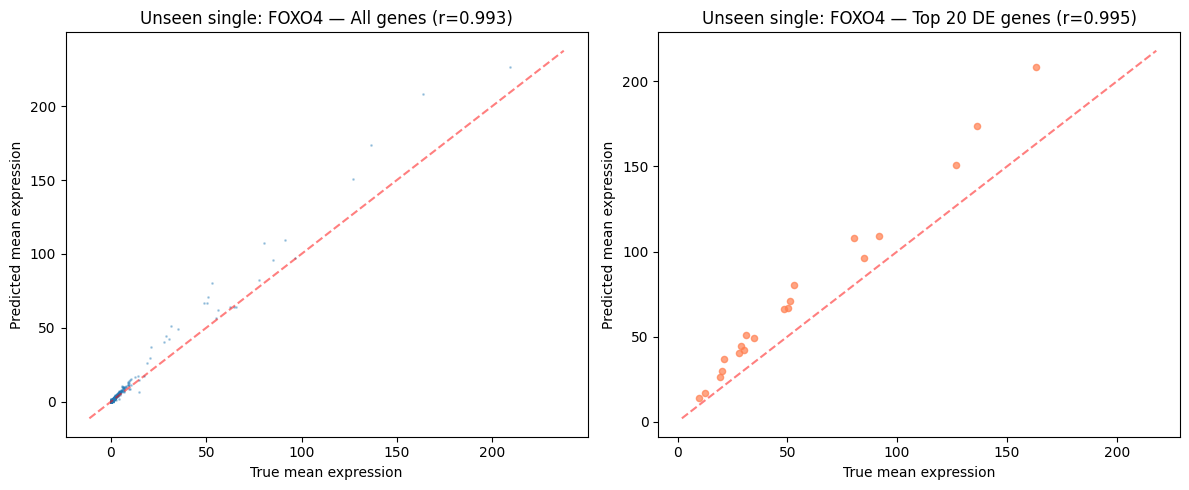

In [32]:
# Unseen single-gene perturbation
if holdout_single:
    pert = holdout_single[0]
    x_c, x_t, x_p = results[pert]
    if x_t is not None:
        plot_prediction_scatter(x_p, x_t, x_c, title=f'Unseen single: {pert}')

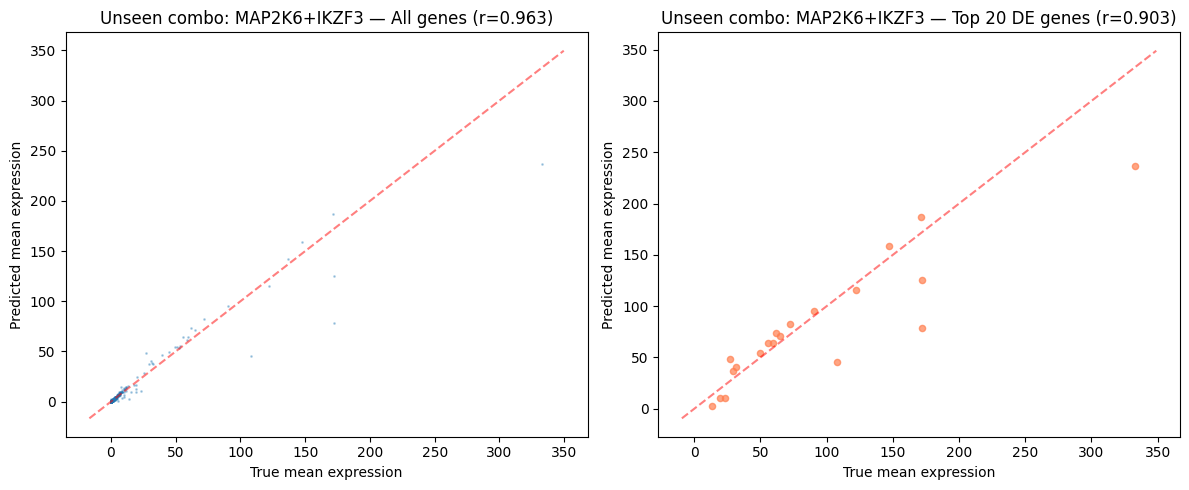

In [33]:
# Unseen combinatorial perturbation
if holdout_combo:
    pert = holdout_combo[0]
    x_c, x_t, x_p = results[pert]
    if x_t is not None:
        plot_prediction_scatter(x_p, x_t, x_c, title=f'Unseen combo: {pert}')

### 7.2 Compare seen vs unseen metric distributions

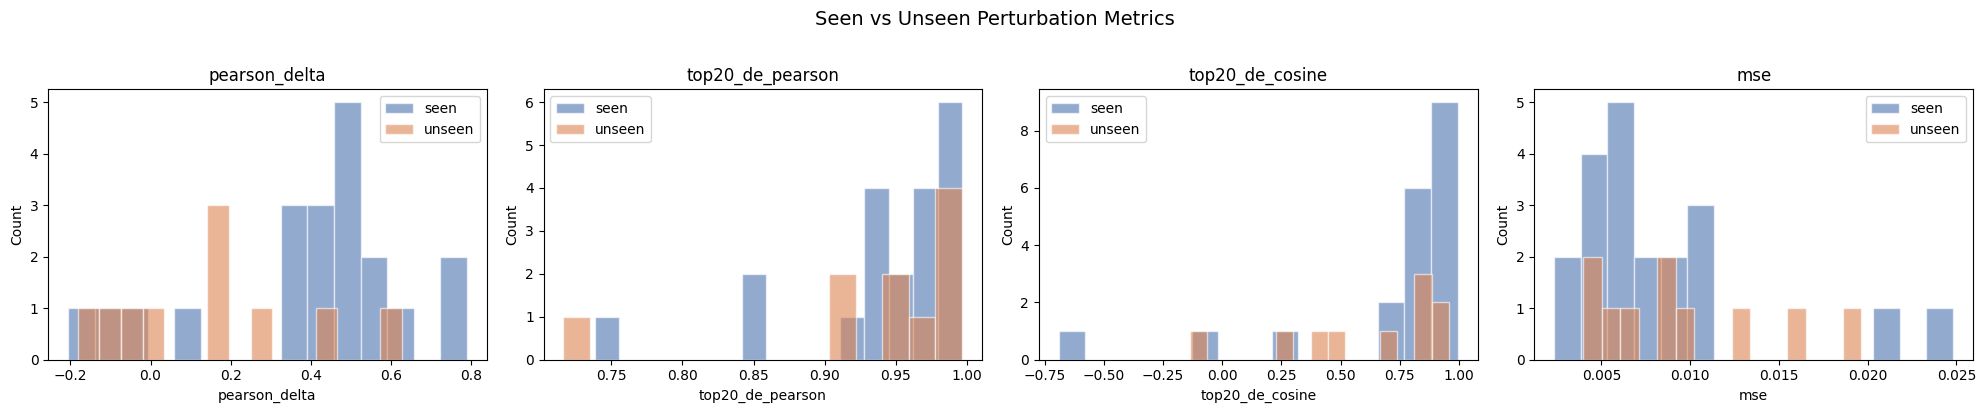

In [34]:
plot_metrics = ['pearson_delta', 'top20_de_pearson', 'top20_de_cosine', 'mse']
available_metrics = [m for m in plot_metrics if m in metrics_df.columns]

fig, axes = plt.subplots(1, len(available_metrics), figsize=(5 * len(available_metrics), 4))
if len(available_metrics) == 1:
    axes = [axes]

colors = {'seen': '#4C72B0', 'unseen': '#DD8452'}

for ax, metric in zip(axes, available_metrics):
    for split in ['seen', 'unseen']:
        sub = metrics_df[metrics_df['split'] == split]
        if len(sub) == 0:
            continue
        vals = sub[metric].dropna()
        ax.hist(vals, bins=15, alpha=0.6, label=split, color=colors[split], edgecolor='white')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')
    ax.legend()
    ax.set_title(metric)

plt.suptitle('Seen vs Unseen Perturbation Metrics', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 7.3 Compare single vs combinatorial perturbation metrics

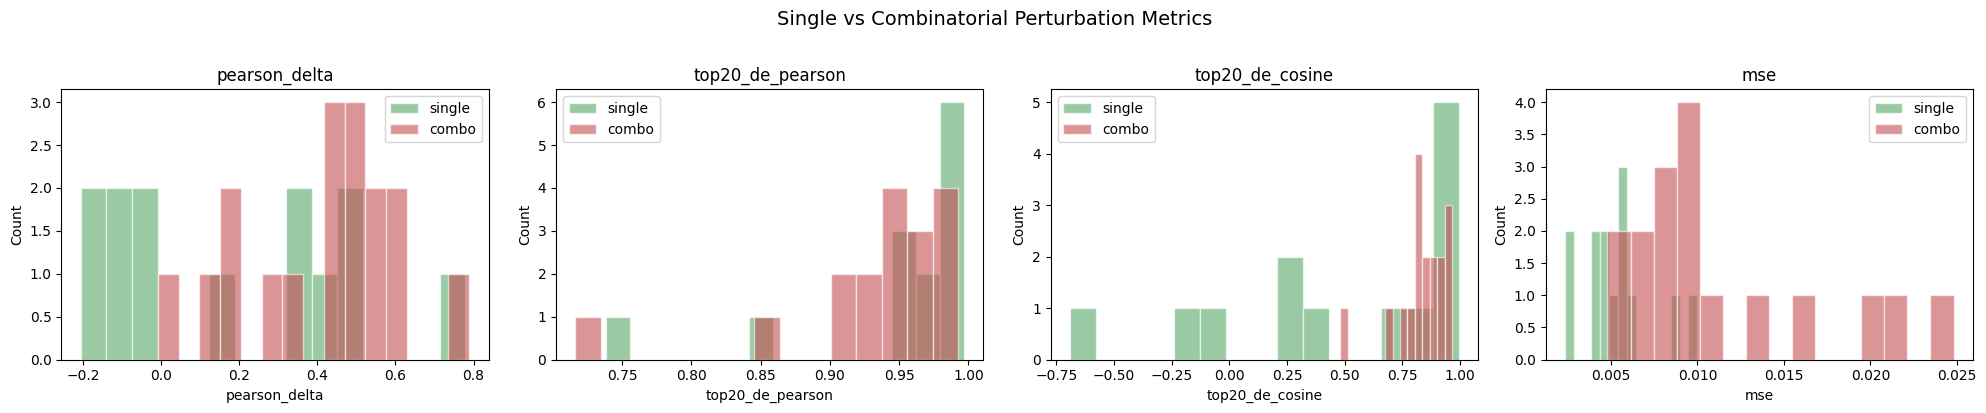

In [35]:
fig, axes = plt.subplots(1, len(available_metrics), figsize=(5 * len(available_metrics), 4))
if len(available_metrics) == 1:
    axes = [axes]

type_colors = {'single': '#55A868', 'combo': '#C44E52'}

for ax, metric in zip(axes, available_metrics):
    for ptype in ['single', 'combo']:
        sub = metrics_df[metrics_df['type'] == ptype]
        if len(sub) == 0:
            continue
        vals = sub[metric].dropna()
        ax.hist(vals, bins=15, alpha=0.6, label=ptype, color=type_colors[ptype], edgecolor='white')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')
    ax.legend()
    ax.set_title(metric)

plt.suptitle('Single vs Combinatorial Perturbation Metrics', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 7.4 Per-perturbation metric bar plot

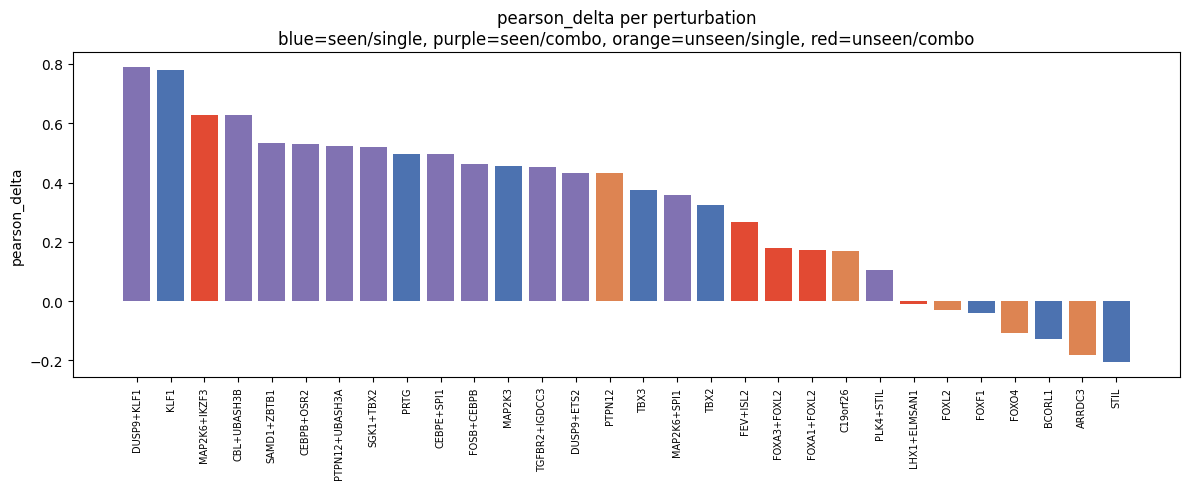

In [36]:
metric_to_plot = 'pearson_delta'
if metric_to_plot in metrics_df.columns:
    df_sorted = metrics_df.sort_values(metric_to_plot, ascending=False)

    bar_colors = []
    for _, row in df_sorted.iterrows():
        if row['split'] == 'unseen' and row['type'] == 'combo':
            bar_colors.append('#E24A33')  # red — unseen combo
        elif row['split'] == 'unseen':
            bar_colors.append('#DD8452')  # orange — unseen single
        elif row['type'] == 'combo':
            bar_colors.append('#8172B2')  # purple — seen combo
        else:
            bar_colors.append('#4C72B0')  # blue — seen single

    fig, ax = plt.subplots(figsize=(max(10, len(df_sorted) * 0.4), 5))
    ax.bar(range(len(df_sorted)), df_sorted[metric_to_plot], color=bar_colors)
    ax.set_xticks(range(len(df_sorted)))
    ax.set_xticklabels(df_sorted.index, rotation=90, fontsize=7)
    ax.set_ylabel(metric_to_plot)
    ax.set_title(f'{metric_to_plot} per perturbation\n'
                 f'blue=seen/single, purple=seen/combo, orange=unseen/single, red=unseen/combo')
    plt.tight_layout()
    plt.show()

### 7.5 Inspect learned perturbation embeddings

In [37]:
names, emb_matrix = model.get_perturbation_embeddings()
print(f"Perturbation embeddings: {len(names)} perturbations, dim={emb_matrix.shape[1]}")
print(f"First 10: {names[:10]}")

Perturbation embeddings: 223 perturbations, dim=1536
First 10: ['AHR', 'AHR+FEV', 'AHR+KLF1', 'ARID1A', 'ATL1', 'BAK1', 'BCL2L11', 'BCL2L11+BAK1', 'BCL2L11+TGFBR2', 'BCORL1']


## 8. Full metrics table

In [38]:
display_cols = [c for c in metrics_df.columns if c not in ('split', 'type')]

print("\n--- UNSEEN SINGLE perturbations ---")
mask = (metrics_df['split'] == 'unseen') & (metrics_df['type'] == 'single')
display(metrics_df[mask][display_cols].round(4))

print("\n--- UNSEEN COMBO perturbations ---")
mask = (metrics_df['split'] == 'unseen') & (metrics_df['type'] == 'combo')
display(metrics_df[mask][display_cols].round(4))

print("\n--- SEEN perturbations (random subset) ---")
mask = metrics_df['split'] == 'seen'
display(metrics_df[mask][display_cols].round(4))


--- UNSEEN SINGLE perturbations ---


,pearson_mean,pearson_delta,mse,top20_de_pearson,top20_de_cosine
perturbation,,,,,
FOXO4,0.9841,-0.1085,0.0100,0.9567,0.3956
FOXL2,0.9883,-0.0294,0.0087,0.9563,0.2600
ARRDC3,0.9912,-0.1817,0.0053,0.9964,-0.1371
C19orf26,0.9926,0.1681,0.0040,0.9722,0.7124
PTPN12,0.9920,0.4329,0.0044,0.9840,0.8952



--- UNSEEN COMBO perturbations ---


,pearson_mean,pearson_delta,mse,top20_de_pearson,top20_de_cosine
perturbation,,,,,
MAP2K6+IKZF3,0.9865,0.6273,0.0067,0.9037,0.9576
FEV+ISL2,0.9787,0.2666,0.0161,0.9052,0.8223
FOXA3+FOXL2,0.9739,0.1796,0.0196,0.9788,0.8317
LHX1+ELMSAN1,0.9848,-0.0081,0.0084,0.7164,0.4803
FOXA1+FOXL2,0.9844,0.1740,0.0129,0.9926,0.8783



--- SEEN perturbations (random subset) ---


,pearson_mean,pearson_delta,mse,top20_de_pearson,top20_de_cosine
perturbation,,,,,
STIL,0.9917,-0.2056,0.0061,0.9934,-0.6895
PLK4+STIL,0.9870,0.1037,0.0094,0.9894,0.7696
BCORL1,0.9917,-0.1271,0.0046,0.9615,-0.0530
CEBPE+SPI1,0.9649,0.4972,0.0248,0.8512,0.8028
CEBPB+OSR2,0.9829,0.5306,0.0108,0.9314,0.8297
TGFBR2+IGDCC3,0.9903,0.4528,0.0064,0.9805,0.8447
FOXF1,0.9923,-0.0397,0.0045,0.9949,0.2522
TBX3,0.9880,0.3738,0.0055,0.7382,0.9405
MAP2K3,0.9937,0.4546,0.0028,0.9809,0.8584


## 9. Summary

In this tutorial we demonstrated an end-to-end perturbation prediction workflow with CellDISECT on the **Norman** combinatorial perturbation dataset:

1. **Data download & preparation**: Downloaded the Norman dataset and GenePT gene embeddings. Normalized perturbation labels by stripping the `ctrl` component from single-gene perturbations (`ctrl+GENE` -> `GENE`), keeping true combinatorial perturbations as `GENEA+GENEB`.
2. **Embedding filtering**: Kept only perturbations whose atomic gene components all have GenePT embeddings.
3. **Train/test split**: Randomly held out both single-gene and combinatorial perturbations for zero-shot evaluation.
4. **Model training**: Trained CellDISECT with GenePT perturbation embeddings. Combinatorial perturbation embeddings are automatically computed by summing atomic component embeddings.
5. **Single perturbation prediction**: Used `predict_perturbation` for individual seen, unseen, and unseen combinatorial perturbations.
6. **Batch evaluation**: Used `predict_perturbations` (plural) to efficiently evaluate all unseen perturbations and a random subset of seen perturbations.
7. **Metrics & visualization**: Compared prediction quality across seen/unseen and single/combinatorial perturbations using Pearson correlation, MSE, and top-DE gene metrics.

In [ ]:
PAM